# Weather Data Analysis

**Author:** Ayisha Mariyam  
**Project Type:** Weather Data Analysis  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  

---
##  Project Overview

Weather data analysis plays an important role in environmental monitoring, climate research, agriculture planning, and disaster management.

This project performs a comprehensive analysis of weather data to understand patterns and relationships between meteorological variables such as temperature, humidity, rainfall, and wind speed.

The objectives of this analysis are:

- Explore and understand the dataset structure
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Engineer new features for deeper insights
- Identify statistical patterns and correlations
- Generate insights from weather trends

This notebook demonstrates a structured data analytics workflow similar to what is used in real-world data analytics projects.

In [94]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (8,5)

print("Libraries loaded successfully")

Libraries loaded successfully


# Data Loading

The first step is to load the dataset and inspect its structure. This helps us understand the dataset before performing analysis.

In [95]:
# Load dataset

df = pd.read_csv(r"E:\VS CODE\The Developer's Arena Internship 6 months\Month 2\Datasets\weather_data.csv")

# Display first rows
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [96]:
# Display last rows

df.tail()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
24995,24995,2013-03-09,Penrith,16.5,30.0,0.0,NaN,NaN,NE,26.0,...,41.0,NaN,NaN,NaN,NaN,21.6,29.4,No,0.0,No
24996,24996,2013-03-10,Penrith,16.7,30.5,0.0,NaN,NaN,NE,24.0,...,44.0,NaN,NaN,NaN,NaN,21.3,29.0,No,0.0,No
24997,24997,2013-03-11,Penrith,18.3,29.8,0.0,NaN,NaN,ENE,26.0,...,49.0,NaN,NaN,NaN,NaN,20.6,28.2,No,0.0,No
24998,24998,2013-03-12,Penrith,17.5,28.1,0.0,NaN,NaN,NNE,22.0,...,54.0,NaN,NaN,NaN,NaN,21.2,26.8,No,0.0,No
24999,24999,2013-03-13,Penrith,15.4,30.9,0.0,NaN,NaN,NE,24.0,...,39.0,NaN,NaN,NaN,NaN,20.0,30.3,No,0.0,No


In [97]:
# Show column names

print(df.columns)

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='str')


# Dataset Overview

Understanding dataset structure helps determine the type of analysis that can be performed.

We inspect:

- Number of rows and columns
- Data types
- Summary statistics

In [98]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     25000 non-null  int64  
 1   Date           25000 non-null  str    
 2   Location       25000 non-null  str    
 3   MinTemp        24669 non-null  float64
 4   MaxTemp        24824 non-null  float64
 5   Rainfall       24721 non-null  float64
 6   Evaporation    9432 non-null   float64
 7   Sunshine       6664 non-null   float64
 8   WindGustDir    21543 non-null  str    
 9   WindGustSpeed  21545 non-null  float64
 10  WindDir9am     21928 non-null  str    
 11  WindDir3pm     23267 non-null  str    
 12  WindSpeed9am   24428 non-null  float64
 13  WindSpeed3pm   23770 non-null  float64
 14  Humidity9am    24609 non-null  float64
 15  Humidity3pm    23936 non-null  float64
 16  Pressure9am    20172 non-null  float64
 17  Pressure3pm    20173 non-null  float64
 18  Cloud9am       14

In [99]:
# Summary statistics

df.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,25000.000000,24669.000000,24824.000000,24721.000000,9432.000000,6664.000000,21545.000000,24428.000000,23770.000000,24609.000000,23936.000000,20172.000000,20173.000000,14136.000000,13815.000000,24755.000000,24082.000000,25000.000000
mean,12499.500000,13.294568,23.990558,2.674467,5.825138,7.811945,37.772755,12.686917,16.837106,69.822951,52.762826,1018.173290,1015.627438,4.251556,4.409265,17.953084,22.507171,2.677376
std,7217.022701,5.848304,6.114348,9.720306,4.871567,3.718698,13.212331,9.136115,9.095719,17.755908,21.210121,6.481112,6.394829,2.968785,2.719235,5.394685,5.954540,9.705604
min,0.000000,-3.300000,6.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,980.500000,979.000000,0.000000,0.000000,0.300000,6.400000,0.000000
25%,6249.750000,8.900000,19.500000,0.000000,3.000000,5.500000,28.000000,6.000000,9.000000,58.000000,37.000000,1013.800000,1011.300000,1.000000,2.000000,14.200000,18.100000,0.000000
50%,12499.500000,14.000000,23.400000,0.000000,4.800000,8.900000,35.000000,11.000000,17.000000,71.000000,54.000000,1018.200000,1015.700000,5.000000,5.000000,18.400000,21.900000,0.000000
75%,18749.250000,17.900000,27.700000,0.600000,7.200000,10.600000,46.000000,19.000000,22.000000,83.000000,68.000000,1022.600000,1020.000000,7.000000,7.000000,21.900000,26.100000,0.800000
max,24999.000000,29.700000,47.300000,371.000000,86.200000,14.000000,135.000000,130.000000,83.000000,100.000000,100.000000,1039.900000,1036.800000,8.000000,8.000000,37.700000,46.700000,371.000000


In [100]:
# Dataset Shape

df.shape

(25000, 25)

# 4. Data Cleaning

Before performing analysis, it is important to ensure that the dataset does not contain missing or inconsistent values.

In [101]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [102]:
# Remove unwanted columns

df = df.drop(columns=['Unnamed: 0'])

In [103]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='str')

### Fix column name issues
--- remove spaces
--- convert to lowercase
--- standardize naming

In [104]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['date', 'location', 'mintemp', 'maxtemp', 'rainfall', 'evaporation',
       'sunshine', 'windgustdir', 'windgustspeed', 'winddir9am', 'winddir3pm',
       'windspeed9am', 'windspeed3pm', 'humidity9am', 'humidity3pm',
       'pressure9am', 'pressure3pm', 'cloud9am', 'cloud3pm', 'temp9am',
       'temp3pm', 'raintoday', 'risk_mm', 'raintomorrow'],
      dtype='str')


### Correcting data type issues

In [105]:
df['date'] = pd.to_datetime(df['date'])

df.dtypes

date             datetime64[us]
location                    str
mintemp                 float64
maxtemp                 float64
rainfall                float64
evaporation             float64
sunshine                float64
windgustdir                 str
windgustspeed           float64
winddir9am                  str
winddir3pm                  str
windspeed9am            float64
windspeed3pm            float64
humidity9am             float64
humidity3pm             float64
pressure9am             float64
pressure3pm             float64
cloud9am                float64
cloud3pm                float64
temp9am                 float64
temp3pm                 float64
raintoday                   str
risk_mm                 float64
raintomorrow                str
dtype: object

### Converting Binary Categorical Columns

Convert columns contain Yes / No values to numeric values for analysis.

In [106]:
df['raintoday'] = df['raintoday'].str.strip().str.lower()
df['raintoday'] = df['raintoday'].map({'no':0, 'yes':1})

In [107]:
df['raintomorrow'] = df['raintomorrow'].str.strip().str.lower()
df['raintomorrow'] = df['raintomorrow'].map({'no':0, 'yes':1})

In [108]:
df

,date,location,mintemp,maxtemp,rainfall,evaporation,sunshine,windgustdir,windgustspeed,winddir9am,...,humidity3pm,pressure9am,pressure3pm,cloud9am,cloud3pm,temp9am,temp3pm,raintoday,risk_mm,raintomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0.0,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0.0,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0.0,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,1.0,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2013-03-09,Penrith,16.5,30.0,0.0,NaN,NaN,NE,26.0,SSE,...,41.0,NaN,NaN,NaN,NaN,21.6,29.4,0.0,0.0,0
24996,2013-03-10,Penrith,16.7,30.5,0.0,NaN,NaN,NE,24.0,ESE,...,44.0,NaN,NaN,NaN,NaN,21.3,29.0,0.0,0.0,0
24997,2013-03-11,Penrith,18.3,29.8,0.0,NaN,NaN,ENE,26.0,NaN,...,49.0,NaN,NaN,NaN,NaN,20.6,28.2,0.0,0.0,0
24998,2013-03-12,Penrith,17.5,28.1,0.0,NaN,NaN,NNE,22.0,S,...,54.0,NaN,NaN,NaN,NaN,21.2,26.8,0.0,0.0,0


In [109]:
# Check Missing Values

df.isnull().sum()

date                 0
location             0
mintemp            331
maxtemp            176
rainfall           279
evaporation      15568
sunshine         18336
windgustdir       3457
windgustspeed     3455
winddir9am        3072
winddir3pm        1733
windspeed9am       572
windspeed3pm      1230
humidity9am        391
humidity3pm       1064
pressure9am       4828
pressure3pm       4827
cloud9am         10864
cloud3pm         11185
temp9am            245
temp3pm            918
raintoday          279
risk_mm              0
raintomorrow         0
dtype: int64

In [110]:
# Fill missing columns

df.fillna(df.mean(numeric_only=True), inplace=True)

,date,location,mintemp,maxtemp,rainfall,evaporation,sunshine,windgustdir,windgustspeed,winddir9am,...,humidity3pm,pressure9am,pressure3pm,cloud9am,cloud3pm,temp9am,temp3pm,raintoday,risk_mm,raintomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,5.825138,7.811945,W,44.0,W,...,22.0,1007.70000,1007.100000,8.000000,4.409265,16.9,21.8,0.0,0.0,0
1,2008-12-02,Albury,7.4,25.1,0.0,5.825138,7.811945,WNW,44.0,NNW,...,25.0,1010.60000,1007.800000,4.251556,4.409265,17.2,24.3,0.0,0.0,0
2,2008-12-03,Albury,12.9,25.7,0.0,5.825138,7.811945,WSW,46.0,W,...,30.0,1007.60000,1008.700000,4.251556,2.000000,21.0,23.2,0.0,0.0,0
3,2008-12-04,Albury,9.2,28.0,0.0,5.825138,7.811945,NE,24.0,SE,...,16.0,1017.60000,1012.800000,4.251556,4.409265,18.1,26.5,0.0,1.0,0
4,2008-12-05,Albury,17.5,32.3,1.0,5.825138,7.811945,W,41.0,ENE,...,33.0,1010.80000,1006.000000,7.000000,8.000000,17.8,29.7,0.0,0.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,2013-03-09,Penrith,16.5,30.0,0.0,5.825138,7.811945,NE,26.0,SSE,...,41.0,1018.17329,1015.627438,4.251556,4.409265,21.6,29.4,0.0,0.0,0
24996,2013-03-10,Penrith,16.7,30.5,0.0,5.825138,7.811945,NE,24.0,ESE,...,44.0,1018.17329,1015.627438,4.251556,4.409265,21.3,29.0,0.0,0.0,0
24997,2013-03-11,Penrith,18.3,29.8,0.0,5.825138,7.811945,ENE,26.0,NaN,...,49.0,1018.17329,1015.627438,4.251556,4.409265,20.6,28.2,0.0,0.0,0
24998,2013-03-12,Penrith,17.5,28.1,0.0,5.825138,7.811945,NNE,22.0,S,...,54.0,1018.17329,1015.627438,4.251556,4.409265,21.2,26.8,0.0,0.0,0


In [111]:
df.isnull().sum()

date                0
location            0
mintemp             0
maxtemp             0
rainfall            0
evaporation         0
sunshine            0
windgustdir      3457
windgustspeed       0
winddir9am       3072
winddir3pm       1733
windspeed9am        0
windspeed3pm        0
humidity9am         0
humidity3pm         0
pressure9am         0
pressure3pm         0
cloud9am            0
cloud3pm            0
temp9am             0
temp3pm             0
raintoday           0
risk_mm             0
raintomorrow        0
dtype: int64

In [112]:
df['windgustdir'].unique()

<StringArray>
[  'W', 'WNW', 'WSW',  'NE', 'NNW',   'N', 'NNE',  'SW', 'ENE', 'SSE',   'S',
  'NW',  'SE', 'ESE',   nan,   'E', 'SSW']
Length: 17, dtype: str

In [113]:
df['winddir9am'].unique()

<StringArray>
[  'W', 'NNW',  'SE', 'ENE',  'SW', 'SSE',   'S',  'NE',   nan, 'SSW',   'N',
 'WSW', 'ESE',   'E',  'NW', 'WNW', 'NNE']
Length: 17, dtype: str

In [114]:
df['winddir3pm'].unique()

<StringArray>
['WNW', 'WSW',   'E',  'NW',   'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW',  'SW',
  'SE',   'N',   'S', 'NNE',   nan,  'NE']
Length: 17, dtype: str

In [115]:
df['windgustdir'] = df['windgustdir'].fillna(df['windgustdir'].mode()[0])

In [116]:
df['winddir9am'] = df['winddir9am'].fillna(df['winddir9am'].mode()[0])

In [117]:
df['winddir3pm'] = df['winddir3pm'].fillna(df['winddir3pm'].mode()[0])

In [118]:
df.isnull().sum()

date             0
location         0
mintemp          0
maxtemp          0
rainfall         0
evaporation      0
sunshine         0
windgustdir      0
windgustspeed    0
winddir9am       0
winddir3pm       0
windspeed9am     0
windspeed3pm     0
humidity9am      0
humidity3pm      0
pressure9am      0
pressure3pm      0
cloud9am         0
cloud3pm         0
temp9am          0
temp3pm          0
raintoday        0
risk_mm          0
raintomorrow     0
dtype: int64

#  Feature Engineering

Feature engineering creates additional useful variables from existing data.

Examples include:

- Temperature difference
- Average weather indicators
- Weather intensity indicators
- Humidity Difference
- Pressure Difference
- Wind Speed Average

In [119]:
df.columns

Index(['date', 'location', 'mintemp', 'maxtemp', 'rainfall', 'evaporation',
       'sunshine', 'windgustdir', 'windgustspeed', 'winddir9am', 'winddir3pm',
       'windspeed9am', 'windspeed3pm', 'humidity9am', 'humidity3pm',
       'pressure9am', 'pressure3pm', 'cloud9am', 'cloud3pm', 'temp9am',
       'temp3pm', 'raintoday', 'risk_mm', 'raintomorrow'],
      dtype='str')

In [120]:
# Temperature range
df["temp_diff"] = df["maxtemp"] - df["mintemp"]

# Average temperature
df["avg_temp"] = (df["maxtemp"] + df["mintemp"]) / 2

# Humidity Difference
df['humidity_diff'] = df['humidity3pm'] - df['humidity9am']

# Pressure Difference
df['pressure_diff'] = df['pressure3pm'] - df['pressure9am']

# Wind Speed Average
df['avg_windspeed'] = (df['windspeed9am'] + df['windspeed3pm']) / 2


df.head()

,date,location,mintemp,maxtemp,rainfall,evaporation,sunshine,windgustdir,windgustspeed,winddir9am,...,temp9am,temp3pm,raintoday,risk_mm,raintomorrow,temp_diff,avg_temp,humidity_diff,pressure_diff,avg_windspeed
0,2008-12-01,Albury,13.4,22.9,0.6,5.825138,7.811945,W,44.0,W,...,16.9,21.8,0.0,0.0,0,9.5,18.15,-49.0,-0.6,22.0
1,2008-12-02,Albury,7.4,25.1,0.0,5.825138,7.811945,WNW,44.0,NNW,...,17.2,24.3,0.0,0.0,0,17.7,16.25,-19.0,-2.8,13.0
2,2008-12-03,Albury,12.9,25.7,0.0,5.825138,7.811945,WSW,46.0,W,...,21.0,23.2,0.0,0.0,0,12.8,19.30,-8.0,1.1,22.5
3,2008-12-04,Albury,9.2,28.0,0.0,5.825138,7.811945,NE,24.0,SE,...,18.1,26.5,0.0,1.0,0,18.8,18.60,-29.0,-4.8,10.0
4,2008-12-05,Albury,17.5,32.3,1.0,5.825138,7.811945,W,41.0,ENE,...,17.8,29.7,0.0,0.2,0,14.8,24.90,-49.0,-4.8,13.5


In [121]:
# Weather intensity indicators

# Heat intensity based on afternoon temperature
df['heat_level'] = pd.cut(
    df['temp3pm'],
    bins=[0, 20, 30, 40, 60],
    labels=['Cool', 'Warm', 'Hot', 'Very Hot']
)


# Rainfall intensity categories
df['rain_intensity'] = pd.cut(
    df['rainfall'],
    bins=[-1, 0, 5, 20, 100],
    labels=['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
)

# Wind intensity based on wind speed
df['wind_intensity'] = pd.cut(
    df['windspeed3pm'],
    bins=[0, 15, 30, 60],
    labels=['Low Wind', 'Moderate Wind', 'Strong Wind']
)

# Humidity level classification
df['humidity_level'] = pd.cut(
    df['humidity3pm'],
    bins=[0, 30, 60, 100],
    labels=['Low Humidity', 'Moderate Humidity', 'High Humidity']
)

# Ooverall Weather Severity Score
df['weather_severity'] = (
    df['rainfall'] +
    df['windspeed3pm'] +
    df['humidity3pm']
)



In [122]:
df.head()

,date,location,mintemp,maxtemp,rainfall,evaporation,sunshine,windgustdir,windgustspeed,winddir9am,...,temp_diff,avg_temp,humidity_diff,pressure_diff,avg_windspeed,heat_level,rain_intensity,wind_intensity,humidity_level,weather_severity
0,2008-12-01,Albury,13.4,22.9,0.6,5.825138,7.811945,W,44.0,W,...,9.5,18.15,-49.0,-0.6,22.0,Warm,Light Rain,Moderate Wind,Low Humidity,46.6
1,2008-12-02,Albury,7.4,25.1,0.0,5.825138,7.811945,WNW,44.0,NNW,...,17.7,16.25,-19.0,-2.8,13.0,Warm,No Rain,Moderate Wind,Low Humidity,47.0
2,2008-12-03,Albury,12.9,25.7,0.0,5.825138,7.811945,WSW,46.0,W,...,12.8,19.30,-8.0,1.1,22.5,Warm,No Rain,Moderate Wind,Low Humidity,56.0
3,2008-12-04,Albury,9.2,28.0,0.0,5.825138,7.811945,NE,24.0,SE,...,18.8,18.60,-29.0,-4.8,10.0,Warm,No Rain,Low Wind,Low Humidity,25.0
4,2008-12-05,Albury,17.5,32.3,1.0,5.825138,7.811945,W,41.0,ENE,...,14.8,24.90,-49.0,-4.8,13.5,Warm,Light Rain,Moderate Wind,Moderate Humidity,54.0


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify patterns and distributions in the dataset.

We analyze:

- Temperature distribution
- Humidity distribution
- Rainfall distribution
- Wind speed patterns
- Weather Trend analysis
- Relationship Analysis
- Categorical analysis
- Boxplot Analysis
- Correlation analysis

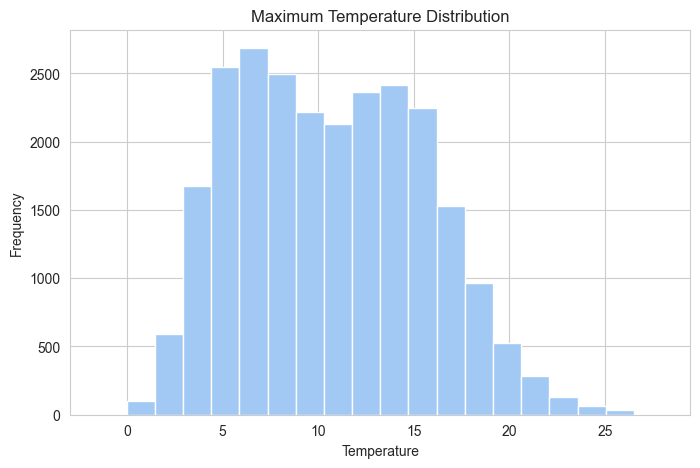

In [123]:
## Temperature Distribution

plt.hist(df["temp_diff"], bins=20)

plt.title("Maximum Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

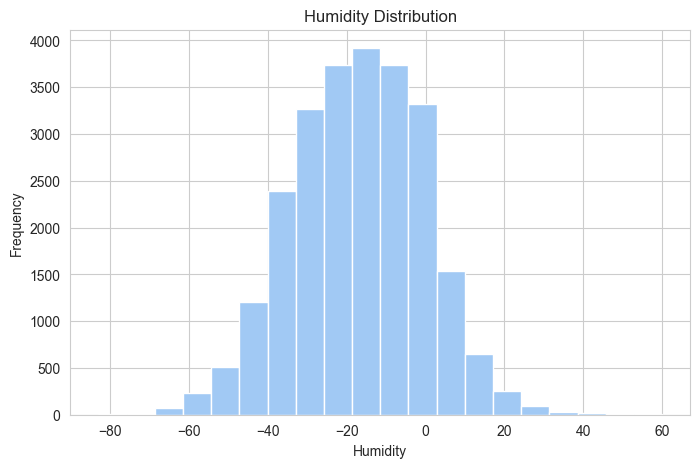

In [124]:
## Humidity Distribution

plt.hist(df["humidity_diff"], bins=20)

plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Frequency")

plt.show()

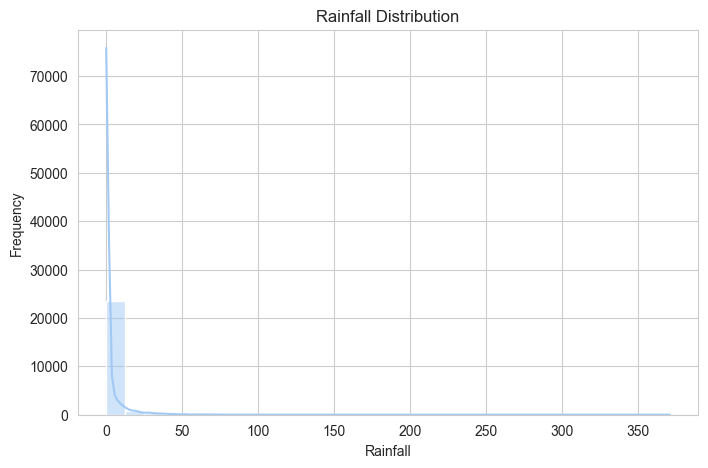

In [125]:
## Rainfall Distribution

sns.histplot(df['rainfall'], bins=30, kde=True)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

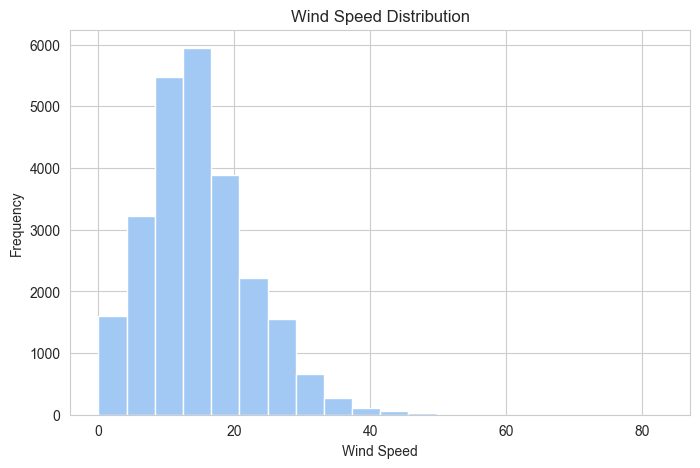

In [126]:
## Wind Speed Distribution

plt.hist(df["avg_windspeed"], bins=20)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

plt.show()

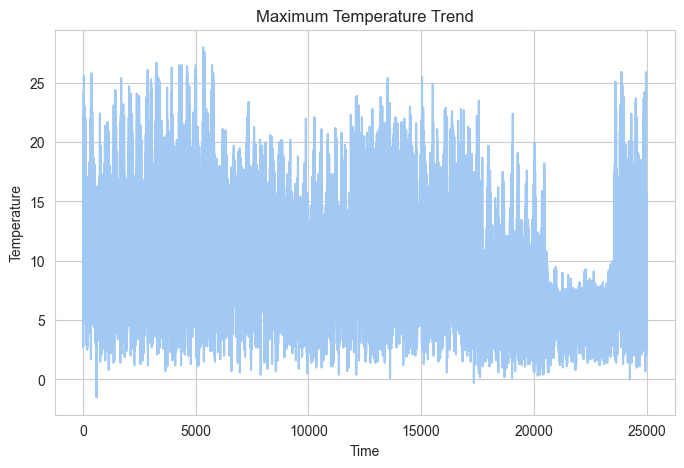

In [127]:
# Weather Trend Analysis

plt.plot(df["temp_diff"])

plt.title("Maximum Temperature Trend")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()

### Relationship Analysis

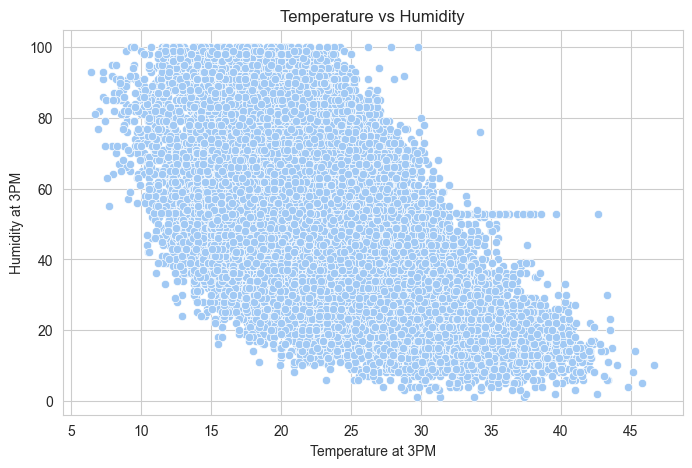

In [128]:
sns.scatterplot(x=df['temp3pm'], y=df['humidity3pm'])

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature at 3PM")
plt.ylabel("Humidity at 3PM")

plt.show()


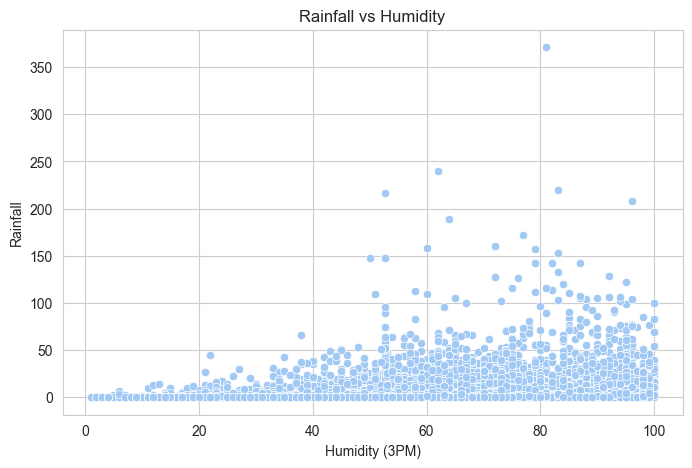

In [129]:
sns.scatterplot(x=df['humidity3pm'], y=df['rainfall'])

plt.title("Rainfall vs Humidity")
plt.xlabel("Humidity (3PM)")
plt.ylabel("Rainfall")

plt.show()

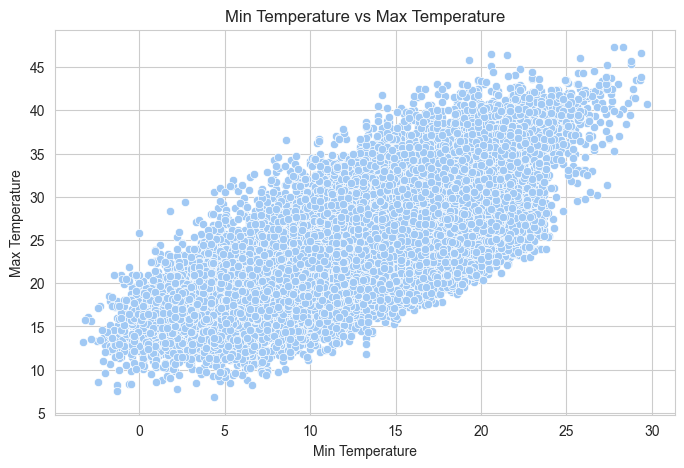

In [130]:
sns.scatterplot(x=df['mintemp'], y=df['maxtemp'])

plt.title("Min Temperature vs Max Temperature")
plt.xlabel("Min Temperature")
plt.ylabel("Max Temperature")

plt.show()

### Categorical Analysis

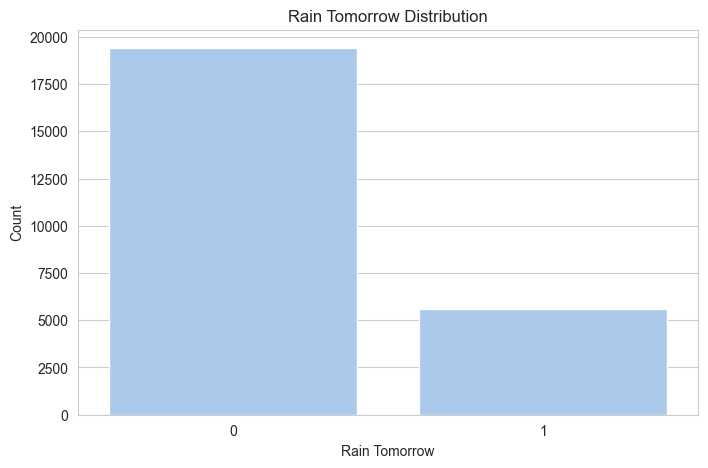

In [131]:
sns.countplot(x=df['raintomorrow'])

plt.title("Rain Tomorrow Distribution")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")

plt.show()

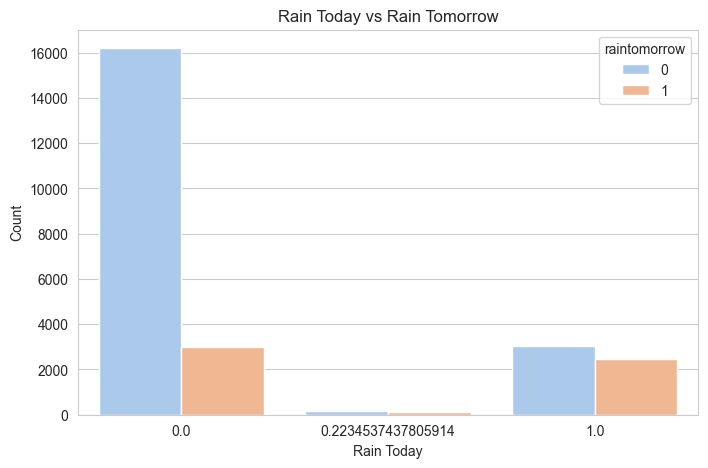

In [132]:
sns.countplot(x=df['raintoday'], hue=df['raintomorrow'])

plt.title("Rain Today vs Rain Tomorrow")
plt.xlabel("Rain Today")
plt.ylabel("Count")

plt.show()

### Boxplot Analysis (Outliers)

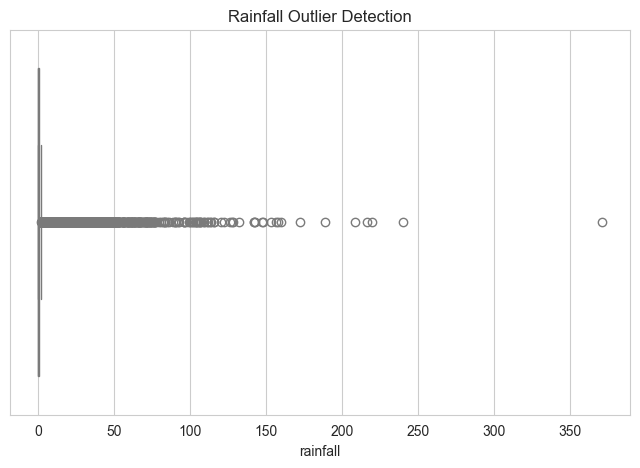

In [133]:
sns.boxplot(x=df['rainfall'])

plt.title("Rainfall Outlier Detection")

plt.show()

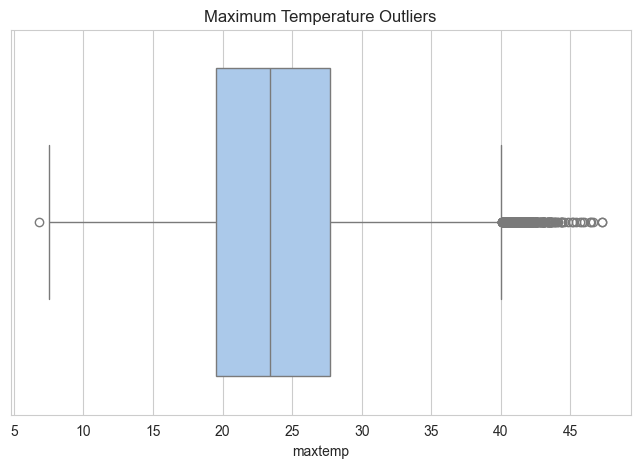

In [134]:
sns.boxplot(x=df['maxtemp'])

plt.title("Maximum Temperature Outliers")

plt.show()

### Correlation Analysis

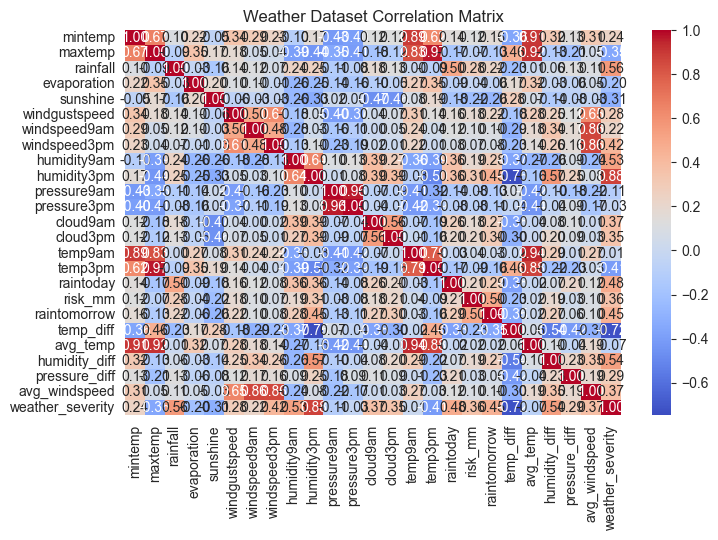

In [135]:
numeric_df = df.select_dtypes(include=['int64','float64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Weather Dataset Correlation Matrix")

plt.show()


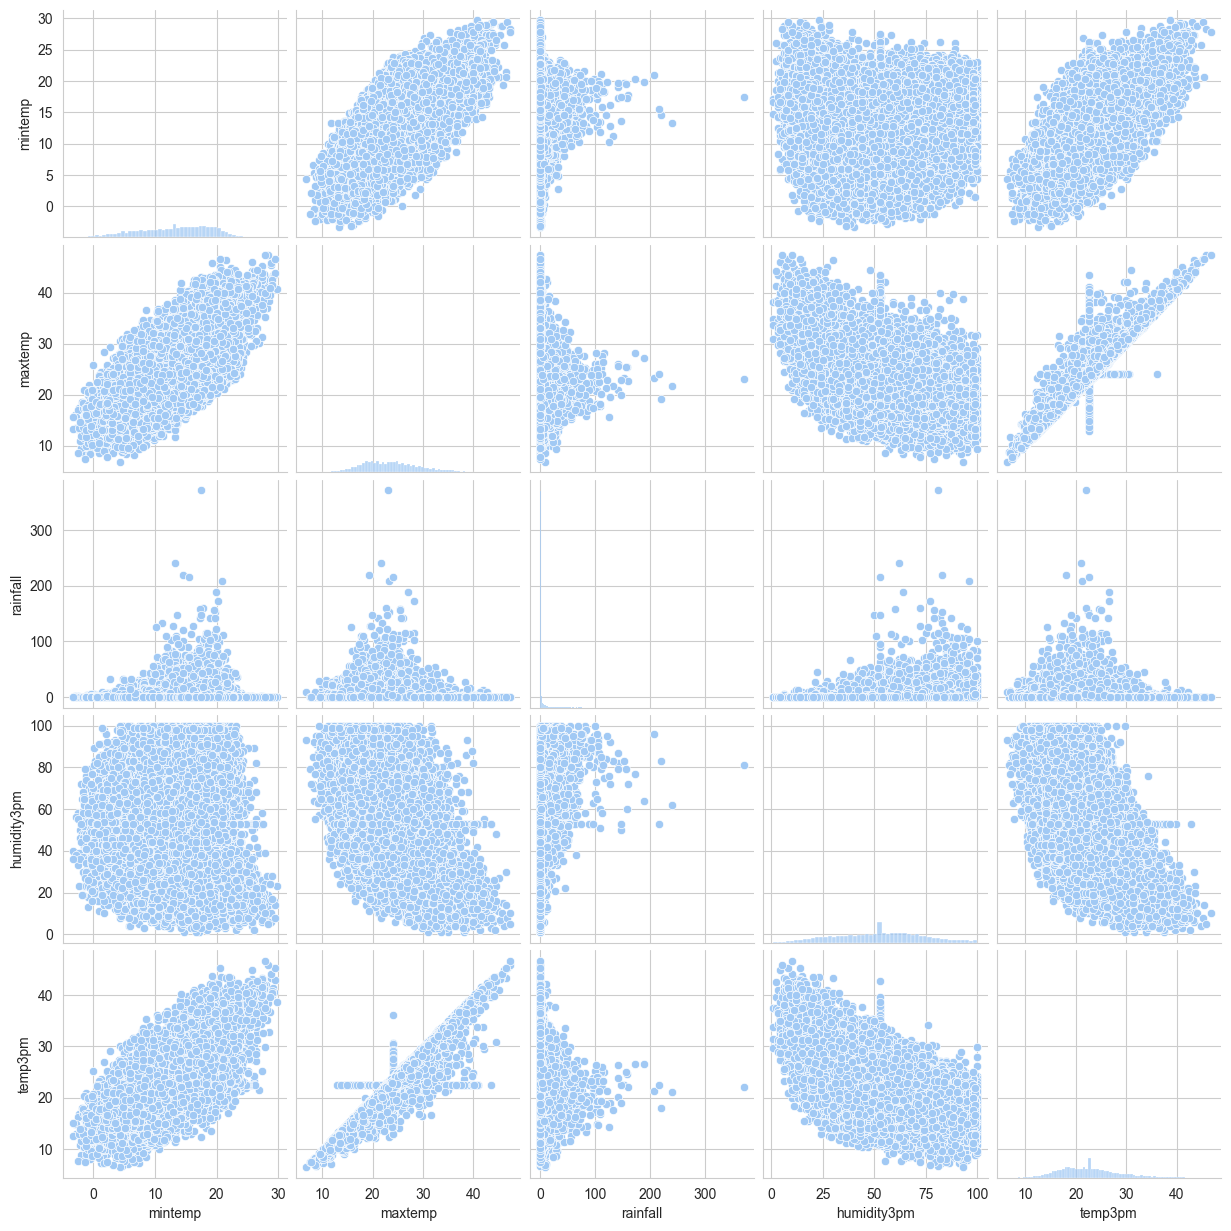

In [136]:
# Pair Plot

sns.pairplot(df[['mintemp','maxtemp','rainfall','humidity3pm','temp3pm']])

plt.show()

In [137]:
correlation_matrix['rainfall'].sort_values(ascending=False)

rainfall            1.000000
weather_severity    0.563087
raintoday           0.498934
risk_mm             0.278910
humidity3pm         0.248563
humidity9am         0.239231
raintomorrow        0.223867
cloud9am            0.178764
windgustspeed       0.142502
cloud3pm            0.132409
pressure_diff       0.129448
windspeed9am        0.116189
avg_windspeed       0.106476
mintemp             0.104184
windspeed3pm        0.066843
humidity_diff       0.057277
avg_temp            0.007174
temp9am             0.004373
evaporation        -0.026994
pressure3pm        -0.079768
maxtemp            -0.086550
temp3pm            -0.086670
pressure9am        -0.113357
sunshine           -0.156993
temp_diff          -0.232262
Name: rainfall, dtype: float64

# Key Insights

The analysis of the weather dataset reveals several important patterns:

- Temperature levels fluctuate significantly across the dataset.
- Higher humidity levels are often associated with rainfall events.
- Wind speed varies depending on atmospheric conditions.
- Temperature range provides insights into daily weather variability.
- Correlation analysis highlights relationships between meteorological variables.

These findings help understand weather behavior and climate patterns.

# Statistical Insights

Key statistical observations include:

- Temperature values show moderate variation.
- Humidity levels demonstrate wide distribution across observations.
- Rainfall occurrences are relatively less frequent but impactful.
- Strong correlations exist between rainfall and humidity variables.

#  Recommendations

Based on the analysis:

1. Weather monitoring systems should track humidity levels to predict rainfall events.
2. Temperature variability should be analyzed to support climate forecasting.
3. Wind speed monitoring can assist in predicting severe weather conditions.
4. Feature engineering can improve predictive weather models.

Weather analytics can support agriculture planning, disaster management, and climate monitoring.

#  Conclusion

This project analyzed a weather dataset using Python-based data analytics techniques.

The workflow included:

- Data cleaning and preprocessing
- Feature engineering
- Exploratory data analysis
- Visualization and statistical analysis

Weather data analysis provides valuable insights into climate patterns and environmental conditions.

Future work may include:

- Weather forecasting models
- Machine learning prediction models
- Seasonal trend analysis